# Import Dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/AI Age Detection Project/DataSet"
print(os.listdir(dataset_path))

['36_1_1_20170115235941456.jpg', '36_1_1_20170116014023777.jpg', '36_1_1_20170115235824976.jpg', '36_1_0_20170117005907450.jpg', '36_1_1_20170116153744623.jpg', '36_1_1_20170116023952972.jpg', '36_1_1_20170116014305365.jpg', '36_1_1_20170116022026435.jpg', '36_1_1_20170116155035948.jpg', '36_1_1_20170116014314127.jpg', '36_1_1_20170116161213859.jpg', '36_1_1_20170116165713429.jpg', '36_1_1_20170116160832540.jpg', '36_1_1_20170116163956549.jpg', '36_1_1_20170116173257960.jpg', '36_1_1_20170116161709695.jpg', '36_1_1_20170116173339947.jpg', '36_1_1_20170116223054510.jpg', '36_1_1_20170116175401101.jpg', '36_1_1_20170116234813239.jpg', '36_1_1_20170116222904910.jpg', '36_1_1_20170116174213892.jpg', '36_1_1_20170116232708069.jpg', '36_1_1_20170116175558494.jpg', '36_1_1_20170117171355933.jpg', '36_1_1_20170117133947127.jpg', '36_1_1_20170117094930388.jpg', '36_1_1_20170117165628076.jpg', '36_1_1_20170117141102516.jpg', '36_1_1_20170117134015960.jpg', '36_1_1_20170117170752063.jpg', '36_1_3

In [ ]:
import os

for root, dirs, files in os.walk(dataset_path):
    print("Root:", root)
    print("Dirs:", dirs)
    print("Files:", files[:5])
    print("-"*50)

Root: /content/drive/MyDrive/AI Age Detection Project/DataSet
Dirs: []
Files: ['36_1_1_20170115235941456.jpg', '36_1_1_20170116014023777.jpg', '36_1_1_20170115235824976.jpg', '36_1_0_20170117005907450.jpg', '36_1_1_20170116153744623.jpg']
--------------------------------------------------


In [ ]:
import os

count = len([
    f for f in os.listdir(dataset_path)
    if f.endswith(".jpg")
])

print("Number of images:", count)

Number of images: 24108


## Load Images

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = "/content/drive/MyDrive/AI Age Detection Project/Split_DataSet/train"
test_dir = "/content/drive/MyDrive/AI Age Detection Project/Split_DataSet/test"

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

print("Train Images:", len(train_dataset))
print("Test Images:", len(test_dataset))
print("Classes:", train_dataset.classes)

Train Images: 13701
Test Images: 3429
Classes: ['18-20', '21-30', '31-40', '41-50', '51-60']


## Create DataLoaders

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(len(train_dataset))
print(train_dataset.classes)

print(len(test_dataset))
print(test_dataset.classes)

13701
['18-20', '21-30', '31-40', '41-50', '51-60']
3429
['18-20', '21-30', '31-40', '41-50', '51-60']


## Visualize Images

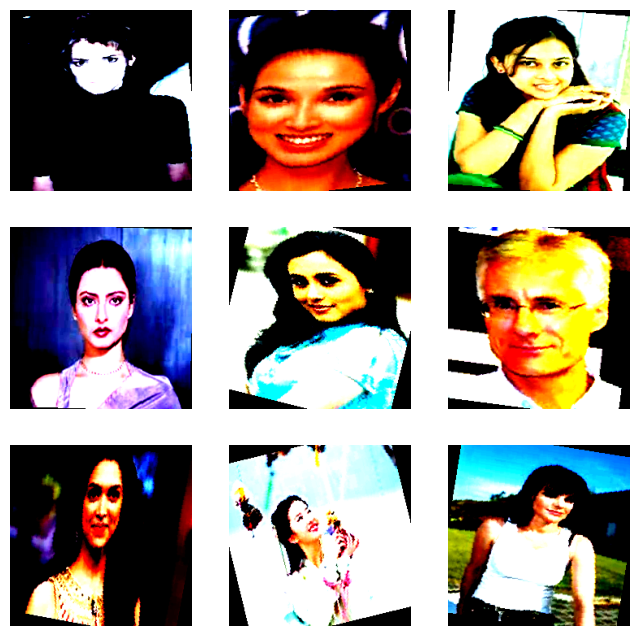

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.axis("off")
plt.show()

# ResNet18

In [ ]:
from torchvision import models
model = models.resnet18(
    weights='DEFAULT'
)

## Replace Last Layer

In [ ]:
import torch.nn as nn
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 5)
)

## Move to GPU

In [ ]:
import torch
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)

In [ ]:
print(device)

cuda


## Define Loss Function

In [ ]:
criterion = nn.CrossEntropyLoss()

## Define Optimizer

In [ ]:
import torch.optim as optim
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

## Training Loop

In [ ]:
from tqdm import tqdm

num_epochs = 10

for epoch in range(num_epochs):

    # Training
    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{num_epochs}",
        leave=True
    )

    for images, labels in train_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

        train_acc = 100 * train_correct / train_total

        train_bar.set_postfix({
            "Loss": f"{loss.item():.4f}",
            "Train Acc": f"{train_acc:.2f}%"
        })

    print(
        f"\nEpoch [{epoch+1}/{num_epochs}] "
        f"| Avg Loss: {running_loss/len(train_loader):.4f} "
        f"| Train Acc: {train_acc:.2f}%"
    )

Epoch 1/10: 100%|██████████| 215/215 [02:41<00:00,  1.33it/s, Loss=1.3742, Train Acc=61.44%]



Epoch [1/10] | Avg Loss: 0.9319 | Train Acc: 61.44%


Epoch 2/10: 100%|██████████| 215/215 [02:41<00:00,  1.33it/s, Loss=1.4160, Train Acc=63.92%]



Epoch [2/10] | Avg Loss: 0.8670 | Train Acc: 63.92%


Epoch 3/10: 100%|██████████| 215/215 [02:43<00:00,  1.32it/s, Loss=0.3418, Train Acc=66.35%]


...


Epoch [8/10] | Avg Loss: 0.4711 | Train Acc: 81.50%


Epoch 9/10: 100%|██████████| 215/215 [02:42<00:00,  1.33it/s, Loss=1.1498, Train Acc=84.09%]



Epoch [9/10] | Avg Loss: 0.4252 | Train Acc: 84.09%


Epoch 10/10: 100%|██████████| 215/215 [02:41<00:00,  1.33it/s, Loss=1.3264, Train Acc=85.31%]


Epoch [10/10] | Avg Loss: 0.3847 | Train Acc: 85.31%


## Evaluate Model

In [ ]:
from tqdm import tqdm

model.eval()

correct = 0
total = 0

with torch.no_grad():

    test_bar = tqdm(
        test_loader,
        desc="Testing",
        leave=True
    )

    for images, labels in test_bar:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

        current_acc = 100 * correct / total

        test_bar.set_postfix({
            "Accuracy": f"{current_acc:.2f}%"
        })

accuracy = 100 * correct / total

print(f"\nFinal Test Accuracy: {accuracy:.2f}%")

Testing: 100%|██████████| 54/54 [06:16<00:00,  6.98s/it, Accuracy=56.69%]


Final Test Accuracy: 56.69%


In [ ]:
from collections import Counter

print(Counter(train_dataset.targets))
print(Counter(test_dataset.targets))

Counter({1: 6244, 2: 3478, 4: 1780, 3: 1682, 0: 517})
Counter({1: 1562, 2: 870, 4: 446, 3: 421, 0: 130})


In [ ]:
print("Train Images:", len(train_dataset))
print("Test Images:", len(test_dataset))

from collections import Counter
print("Train:", Counter(train_dataset.targets))
print("Test:", Counter(test_dataset.targets))

Train Images: 13701
Test Images: 3429
Train: Counter({1: 6244, 2: 3478, 4: 1780, 3: 1682, 0: 517})
Test: Counter({1: 1562, 2: 870, 4: 446, 3: 421, 0: 130})


### Check per-class performance

In [ ]:
from sklearn.metrics import classification_report
import torch

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = outputs.argmax(1).cpu()

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

print(classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

       18-20       0.45      0.18      0.25       130
       21-30       0.67      0.83      0.74      1562
       31-40       0.41      0.43      0.42       870
       41-50       0.30      0.18      0.23       421
       51-60       0.67      0.39      0.49       446

    accuracy                           0.57      3429
   macro avg       0.50      0.40      0.43      3429
weighted avg       0.55      0.57      0.54      3429



### Plot a confusion matrix

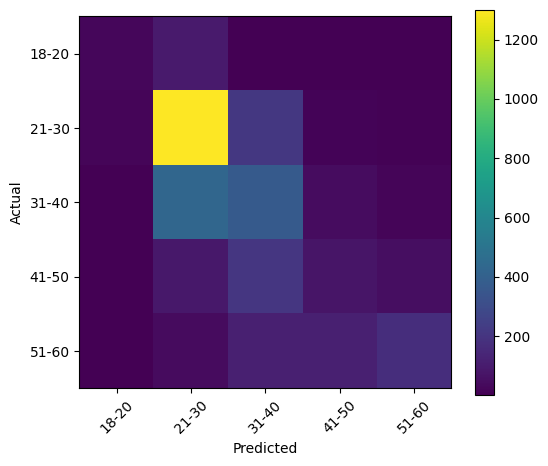

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(5), train_dataset.classes, rotation=45)
plt.yticks(range(5), train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "resnet18_age_detection.pth"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
torch.save(
    model,
    "complete_resnet18_age_detection.pth"
)

## Checking for custom Image

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = models.resnet18(weights=None)

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 5)
)

model.load_state_dict(
    torch.load(
        "resnet18_age_detection.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Define Image Transform

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

### Load Custom Image

In [ ]:
from google.colab import files
from PIL import Image

image_path = "my_image.jpg"

uploaded = files.upload()

# Get filename
image_path = list(uploaded.keys())[0]

# Open image
image = Image.open(image_path).convert("RGB")

image = transform(image)

image = image.unsqueeze(0)

image = image.to(device)

Saving Screenshot 2024-12-10 135310.png to Screenshot 2024-12-10 135310.png


### Predict Age Group

In [ ]:
with torch.no_grad():

    outputs = model(image)

    _, prediction = torch.max(outputs, 1)

predicted_class = prediction.item()

print(predicted_class)

1


### Convert Class Number to Age Group

In [ ]:
class_names = [
    "18-20",
    "21-30",
    "31-40",
    "41-50",
    "51-60"
]

print(
    "Predicted Age Group:",
    class_names[predicted_class]
)

Predicted Age Group: 21-30


### Show Confidence

In [ ]:
import torch.nn.functional as F

with torch.no_grad():

    outputs = model(image)

    probs = F.softmax(outputs, dim=1)

    confidence, prediction = torch.max(
        probs,
        1
    )

print(
    f"Age Group: {class_names[prediction.item()]}"
)

print(
    f"Confidence: {confidence.item()*100:.2f}%"
)

Age Group: 21-30
Confidence: 63.00%
